# Transcription Integration

Speech-to-text via Whisper or YouTube captions.

The transcription endpoint supports a `use_youtube_captions` flag:

- **`use_youtube_captions=True`** (default): YouTube captions are preferred when available, skipping Whisper entirely. This is faster since no GPU inference is needed. If YouTube captions are not available, Whisper runs as a fallback.
- **`use_youtube_captions=False`**: Whisper STT always runs on the video's audio track, regardless of whether YouTube captions exist. This produces more accurate timestamps and can provide word-level detail.

The transcription result is cached as JSON in `pipeline_data/api/transcriptions/whisper/`. Subsequent calls with `use_youtube_captions=True` return the cached result with `skipped=True`.

## Setup

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

video_id = "GYQ5yGV_-Oc"

class _NoopSpan:
    def __enter__(self): return self
    def __exit__(self, *a): pass
class _noop:
    @staticmethod
    def span(name, **kw): return _NoopSpan()
    @staticmethod
    def info(*a, **kw): pass
logfire = _noop()

print(f"Project root: {PROJECT_ROOT}")
print(f"Video ID: {video_id}")

Project root: /Users/adit/Documents/Coding/AIAssignments/AiProject/foreign-whispers
Video ID: GYQ5yGV_-Oc


## Run Transcription

The transcription endpoint has two modes:

1. **YouTube captions mode** (`use_youtube_captions=True`): Downloads and converts YouTube's auto-generated or manual captions into Whisper-compatible segment format. Fast, no GPU needed.
2. **Whisper STT mode** (`use_youtube_captions=False`): Runs the Whisper model on the video's audio track. Slower but produces higher-quality timestamps.

The `FWClient.transcribe()` method uses the default (YouTube captions). To force Whisper, we call the API directly with the query parameter.

In [4]:
import json
from pathlib import Path

video_id = "GYQ5yGV_-Oc"
captions_dir = PROJECT_ROOT / "pipeline_data" / "api" / "youtube_captions"

yt_segments = json.loads((captions_dir / f"{video_id}.json").read_text())

print(f"Loaded {len(yt_segments)} YouTube caption segments")
for seg in yt_segments[:3]:
    duration = seg["end"] - seg["start"]
    print(f"  [{seg['start']:.2f}s - {seg['end']:.2f}s] ({duration:.2f}s) {seg['text']}")

Loaded 338 YouTube caption segments
  [2.00s - 6.00s] (4.00s) 60<00:00:02.720><c> Minutes</c><00:00:03.120><c> overtime.</c>
  [6.00s - 7.00s] (1.00s) What's<00:00:06.720><c> the</c><00:00:06.879><c> worst</c><00:00:07.200><c> case</c><00:00:07.359><c> scenario</c><00:00:07.759><c> that</c>
  [7.00s - 8.00s] (1.00s) What's the worst case scenario that


In [5]:
import re

def clean_vtt_text(text):
    # Remove <00:00:00.000> style timestamps and <c> tags
    text = re.sub(r'<[^>]+>', '', text)
    # Collapse extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Clean all segments
for seg in yt_segments:
    seg["text"] = clean_vtt_text(seg["text"])

# Save cleaned version back to disk
captions_dir = PROJECT_ROOT / "pipeline_data" / "api" / "youtube_captions"
import json
(captions_dir / f"{video_id}.json").write_text(json.dumps(yt_segments, indent=2))

print(f"Cleaned {len(yt_segments)} segments")
for seg in yt_segments[:3]:
    duration = seg["end"] - seg["start"]
    print(f"  [{seg['start']:.2f}s - {seg['end']:.2f}s] ({duration:.2f}s) {seg['text']}")

Cleaned 338 segments
  [2.00s - 6.00s] (4.00s) 60 Minutes overtime.
  [6.00s - 7.00s] (1.00s) What's the worst case scenario that
  [7.00s - 8.00s] (1.00s) What's the worst case scenario that


## Force Whisper STT

You may want to force Whisper over YouTube captions when you need:

- **More accurate timestamps**: Whisper uses acoustic features to precisely locate speech boundaries, while YouTube captions often have coarser timing.
- **Word-level detail**: Whisper can produce word-level timestamps, useful for precise alignment in the TTS stage.
- **Consistency**: YouTube captions vary in quality across videos; Whisper provides a uniform baseline.

In [6]:
import whisper
import json

transcriptions_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
transcriptions_dir.mkdir(parents=True, exist_ok=True)

video_path = PROJECT_ROOT / "pipeline_data" / "api" / "videos" / f"{video_id}.mp4"

model = whisper.load_model("base")
result = model.transcribe(str(video_path))

whisper_segments = result["segments"]

# Save to disk
out = {"language": result["language"], "text": result["text"], "segments": whisper_segments}
(transcriptions_dir / f"{video_id}.json").write_text(json.dumps(out, indent=2))

print(f"Language: {result['language']}")
print(f"Segments: {len(whisper_segments)}")
for seg in whisper_segments[:3]:
    duration = seg["end"] - seg["start"]
    print(f"  [{seg['start']:.2f}s - {seg['end']:.2f}s] ({duration:.2f}s) {seg['text']}")

100%|███████████████████████████████████████| 139M/139M [00:08<00:00, 18.1MiB/s]
/Users/adit/Documents/Coding/AIAssignments/AiProject/foreign-whispers/.venv/lib/python3.11/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Language: en
Segments: 98
  [0.00s - 3.60s] (3.60s)  60 minutes over time.
  [3.60s - 9.52s] (5.92s)  What's the worst case scenario that you're worried about?
  [9.52s - 15.60s] (6.08s)  Is that it is closed for weeks and weeks and weeks here and you start to see the global


## Compare YouTube vs Whisper Segments

When both transcriptions are available, we can compare their segment characteristics:
- Segment count differences (YouTube captions often have fewer, longer segments)
- Duration distribution (Whisper tends to produce more uniform segment lengths)

YouTube captions: 338 segments, avg duration 1.19s
Whisper STT:      98 segments, avg duration 4.14s


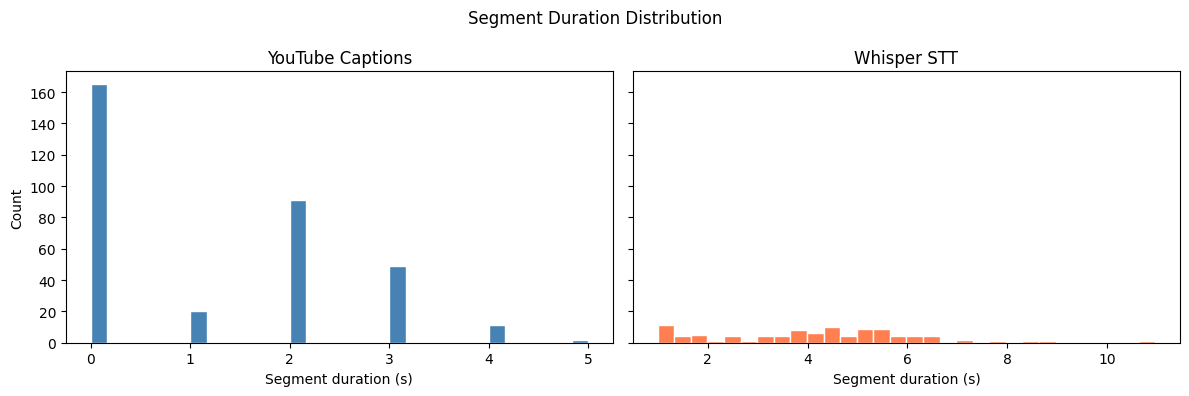

In [7]:
import matplotlib.pyplot as plt

yt_durations = [s["end"] - s["start"] for s in yt_segments]
whisper_durations = [s["end"] - s["start"] for s in whisper_segments]

print(f"YouTube captions: {len(yt_segments)} segments, avg duration {sum(yt_durations)/len(yt_durations):.2f}s")
print(f"Whisper STT:      {len(whisper_segments)} segments, avg duration {sum(whisper_durations)/len(whisper_durations):.2f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(yt_durations, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("YouTube Captions")
axes[0].set_xlabel("Segment duration (s)")
axes[0].set_ylabel("Count")

axes[1].hist(whisper_durations, bins=30, color="coral", edgecolor="white")
axes[1].set_title("Whisper STT")
axes[1].set_xlabel("Segment duration (s)")

fig.suptitle("Segment Duration Distribution")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "segment_duration_comparison.png", dpi=150)
plt.show()

## Inspect Transcription JSON Structure

Each transcription is stored as a JSON file with the following top-level keys:
- `language`: detected source language code (e.g. `"en"`)
- `text`: full concatenated transcript text
- `segments`: list of segment objects with timing and text

In [ ]:
import json

# Load one transcription JSON and inspect its structure
transcriptions_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
transcription_files = list(transcriptions_dir.glob("*.json"))

if transcription_files:
    data = json.loads(transcription_files[0].read_text())
    print(f"File: {transcription_files[0].name}")
    print(f"Top-level keys: {list(data.keys())}")
    print(f"Language: {data.get('language')}")
    print(f"Total segments: {len(data.get('segments', []))}")
    print()
    print("First 2 segments:")
    print(json.dumps(data["segments"][:2], indent=2))
else:
    print("No transcription files found on disk. Run the transcription step first.")

## Summary

The transcription stage produces a JSON file per video in:

```
pipeline_data/api/transcriptions/whisper/<title>.json
```

Each segment in the JSON has the format:

```json
{
  "id": 0,
  "start": 0.0,
  "end": 3.5,
  "text": "Hello world"
}
```

This output feeds into the next pipeline stage (translation via argostranslate).